# Homework 01: Overfitting and How to Fix It

**Student Version**

**Release:** May 21, 2026  
**Deadline:** May 24, 2026  
**Recommended time budget:** 3-5 focused hours  
**Recommended environment:** Google Colab or a local Python environment with PyTorch and torchvision. A GPU is helpful but not required for the required path.

In this homework you will build a working image classifier, intentionally make it overfit, and then improve it with regularization. The goal is not to chase the best possible FashionMNIST score. The goal is to show that you can diagnose training behavior and make a fair comparison between experiments.

Goals for this homework:
- Build a full PyTorch training pipeline on **FashionMNIST**
- Train a baseline model and reach a reasonable test-set result
- Demonstrate **overfitting** with clear evidence
- Reduce overfitting using methods from class
- Perform error analysis and summarize your experiments

Minimum viable submission:
- one baseline MLP experiment
- one deliberately overfitting experiment
- one regularized/improved experiment
- learning curves for the main experiments
- confusion matrix or misclassification examples for your best model
- a short summary table and written answers

Suggested success criteria:
- **Task 1:** reach about **86% test accuracy** with a baseline MLP; slightly lower is acceptable if the experiment is correct and analyzed honestly
- **Task 2:** show a clear train/validation gap, or validation loss getting worse while training loss improves
- **Task 3:** reduce the gap and/or improve validation/test behavior using at least two regularization choices

Grading guide:

| Part | Weight | What matters most |
|---|---:|---|
| Task 1: baseline | 20% | working training loop, metrics, learning curves, test accuracy |
| Task 2: overfitting evidence | 25% | convincing train/validation evidence and explanation |
| Task 3: fix | 25% | fair comparison, at least two improvements, better generalization behavior |
| Task 4: error analysis | 15% | confusion matrix or mistakes, useful interpretation |
| Task 5 + written answers | 15% | clear summary table, concise conclusions, reproducibility |

Keep your notebook readable. A grader should be able to rerun it from top to bottom after you remove or resolve the `NotImplementedError` cells.


## 0. Setup

The helper code below is provided to keep the homework focused on modeling, experiments, and analysis rather than boilerplate.

In [10]:
import copy
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class TransformedSubset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def build_loaders(train_transform, eval_transform, batch_size=128, val_size=5000, train_limit=None, seed=42):
    train_base = datasets.FashionMNIST(root='data', train=True, download=True, transform=None)
    test_base = datasets.FashionMNIST(root='data', train=False, download=True, transform=None)

    generator = torch.Generator().manual_seed(seed)
    all_indices = torch.randperm(len(train_base), generator=generator).tolist()
    val_indices = all_indices[:val_size]
    train_indices = all_indices[val_size:]
    if train_limit is not None:
        train_indices = train_indices[:train_limit]

    train_ds = TransformedSubset(train_base, train_indices, transform=train_transform)
    val_ds = TransformedSubset(train_base, val_indices, transform=eval_transform)
    test_ds = TransformedSubset(test_base, range(len(test_base)), transform=eval_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, val_loader, test_loader, train_base.classes


def show_batch(loader, class_names, max_items=8):
    images, labels = next(iter(loader))
    max_items = min(max_items, len(images))
    fig, axes = plt.subplots(1, max_items, figsize=(1.8 * max_items, 2.6))
    if max_items == 1:
        axes = [axes]
    for ax, image, label in zip(axes, images[:max_items], labels[:max_items]):
        ax.imshow(image.squeeze(0), cmap='gray')
        ax.set_title(class_names[label])
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def accuracy_from_logits(logits, targets):
    predictions = logits.argmax(dim=1)
    return (predictions == targets).float().mean().item()


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)

    return {
        'loss': total_loss / total_examples,
        'acc': total_correct / total_examples,
    }


def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    history = []
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_acc': train_metrics['acc'],
            'val_loss': val_metrics['loss'],
            'val_acc': val_metrics['acc'],
        })
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f}"
        )
    return pd.DataFrame(history)


def evaluate_model(model, loader, criterion):
    return run_epoch(model, loader, criterion, optimizer=None)


def plot_history(history_df, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train loss')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val loss')
    axes[0].set_title(f'{title}: loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['train_acc'], label='train acc')
    axes[1].plot(history_df['epoch'], history_df['val_acc'], label='val acc')
    axes[1].set_title(f'{title}: accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def collect_predictions(model, loader):
    model.eval()
    all_images, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            preds = logits.argmax(dim=1).cpu()
            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds)
    return torch.cat(all_images), torch.cat(all_labels), torch.cat(all_preds)


def show_misclassifications(images, labels, preds, class_names, max_items=8):
    wrong = torch.nonzero(labels != preds).squeeze(1)
    if len(wrong) == 0:
        print('No mistakes found.')
        return
    max_items = min(max_items, len(wrong))
    fig, axes = plt.subplots(1, max_items, figsize=(2.2 * max_items, 3.0))
    if max_items == 1:
        axes = [axes]
    for ax, idx in zip(axes, wrong[:max_items]):
        ax.imshow(images[idx].squeeze(0), cmap='gray')
        ax.set_title(f'T: {class_names[labels[idx]]}\nP: {class_names[preds[idx]]}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


set_seed(42)


Using device: cpu


## Helper Function Contracts

The setup cell above defines helper functions so you do not have to write all boilerplate from scratch. Use them whenever a task asks you to create loaders, train a model, plot curves, evaluate, or inspect mistakes.

| Helper | Use it when | Inputs | Returns |
|---|---|---|---|
| `build_loaders(train_transform, eval_transform, batch_size=128, val_size=5000, train_limit=None, seed=42)` | You need FashionMNIST train/validation/test loaders | training transform, evaluation transform, batch size, validation size, optional train subset size, seed | `train_loader, val_loader, test_loader, class_names, train_size` |
| `show_batch(loader, class_names, max_items=8)` | You want to inspect a few images from a loader | data loader, class name list, number of images | displays a figure, returns nothing |
| `fit_model(model, train_loader, val_loader, criterion, optimizer, epochs)` | You need to train a model and track metrics | model, train/validation loaders, loss, optimizer, epoch count | pandas `DataFrame` with `epoch`, `train_loss`, `train_acc`, `val_loss`, `val_acc` |
| `evaluate_model(model, loader, criterion)` | You need final validation/test metrics | model, loader, loss | dictionary with `loss` and `acc` |
| `plot_history(history_df, title)` | You need learning curves | history DataFrame from `fit_model`, plot title | displays loss and accuracy curves, returns nothing |
| `collect_predictions(model, loader)` | You need predictions for error analysis | trained model, loader | `images, labels, preds` tensors on CPU |
| `show_misclassifications(images, labels, preds, class_names, max_items=8)` | You need to view wrong predictions | tensors from `collect_predictions`, class names, number of examples | displays misclassified examples, returns nothing |

You can still write your own code if you want, but the required path is designed around these helpers.


## 1. Load FashionMNIST and inspect the data

### Exercise 1.1
Define your training and evaluation transforms, create loaders, and inspect one batch.

Required:
- use `transforms.ToTensor()` for the baseline transform
- create train, validation, and test loaders with `build_loaders(...)`
- print or display the class names
- visualize one small batch with `show_batch`

Hints:
- Use the **full training split** for Task 1.
- For Tasks 2 and 3 you may use a smaller training subset, such as 4k or 5k images, to make overfitting easier to observe and keep runtime manageable.


/home/reddonut/HS/year2/module12/Intro_To_Deep_Learning/env/lib64/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


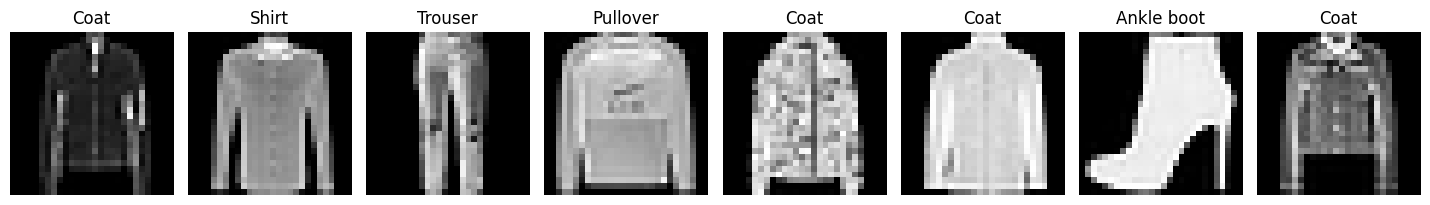

Training examples: 55000


In [11]:
# Exercise 1.1

# TODO:
# 1. define baseline_train_transform and baseline_eval_transform
baseline_train_transform = transforms.Compose([
    transforms.ToTensor(),
])
baseline_eval_transform = transforms.Compose([
    transforms.ToTensor(),
])
# 2. create baseline_train_loader, baseline_val_loader, baseline_test_loader, class_names, baseline_train_size
baseline_train_loader, baseline_val_loader, baseline_test_loader, class_names = build_loaders(
    train_transform=baseline_train_transform,
    eval_transform=baseline_eval_transform,
    batch_size=128,
    val_size=5000,
    train_limit=None,
    seed=42,
)
# 3. visualize a batch
show_batch(baseline_train_loader, class_names)
print('Training examples:', len(baseline_train_loader.dataset))

# Example starting point:
# baseline_train_transform = transforms.Compose([
#     transforms.ToTensor(),
# ])
# baseline_eval_transform = transforms.Compose([
#     transforms.ToTensor(),
# ])
# baseline_train_loader, baseline_val_loader, baseline_test_loader, class_names, baseline_train_size = build_loaders(
#     train_transform=baseline_train_transform,
#     eval_transform=baseline_eval_transform,
#     batch_size=128,
#     val_size=5000,
#     train_limit=None,
#     seed=42,
# )
# show_batch(baseline_train_loader, class_names)
# print('Training examples:', baseline_train_size)

#raise NotImplementedError('Fill in Exercise 1.1')


## 2. Task 1: Build a baseline model

Build a **baseline MLP** and train it end-to-end.

Requirements:
- Use a clean training loop
- Track **train** and **validation** metrics per epoch
- Plot learning curves with `plot_history(...)`
- Report final **test accuracy** with `evaluate_model(...)`
- Try to reach around **86%** test accuracy

Keep the model modest. A good baseline for this homework is a small MLP with `Flatten -> Linear -> ReLU -> Linear -> ReLU -> Linear`.

Use `fit_model(...)` for training unless you intentionally want to write your own loop. Do not spend too long tuning this model. If your code is correct and your result is close, move on to the overfitting and regularization comparison.


Epoch 01 | train_loss=0.5967 train_acc=0.7963 | val_loss=0.4670 val_acc=0.8366
Epoch 02 | train_loss=0.4264 train_acc=0.8505 | val_loss=0.4156 val_acc=0.8506
Epoch 03 | train_loss=0.3868 train_acc=0.8639 | val_loss=0.4155 val_acc=0.8504
Epoch 04 | train_loss=0.3601 train_acc=0.8713 | val_loss=0.3786 val_acc=0.8622
Epoch 05 | train_loss=0.3402 train_acc=0.8787 | val_loss=0.3867 val_acc=0.8596
Epoch 06 | train_loss=0.3251 train_acc=0.8834 | val_loss=0.3663 val_acc=0.8722
Epoch 07 | train_loss=0.3087 train_acc=0.8902 | val_loss=0.3504 val_acc=0.8750
Epoch 08 | train_loss=0.2954 train_acc=0.8939 | val_loss=0.3493 val_acc=0.8714
Epoch 09 | train_loss=0.2864 train_acc=0.8963 | val_loss=0.3487 val_acc=0.8768
Epoch 10 | train_loss=0.2761 train_acc=0.8993 | val_loss=0.3423 val_acc=0.8756
Epoch 11 | train_loss=0.2682 train_acc=0.9027 | val_loss=0.3460 val_acc=0.8744
Epoch 12 | train_loss=0.2593 train_acc=0.9050 | val_loss=0.3490 val_acc=0.8728
Epoch 13 | train_loss=0.2547 train_acc=0.9072 | val_

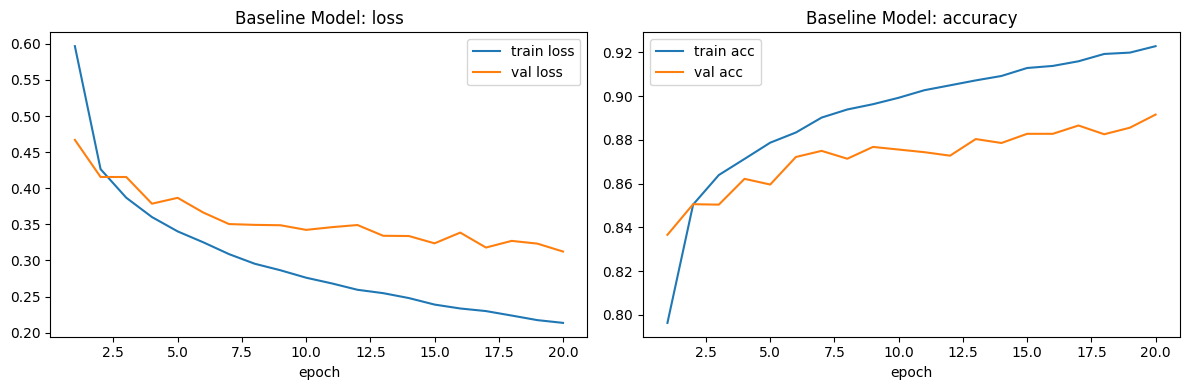

Baseline test loss: 0.3282, test acc: 0.8838
Baseline gap: 0.0313


In [12]:
# Task 1

# TODO:
# 1. define a baseline model class
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
# 2. instantiate the model on `device`
baseline_model = BaselineModel().to(device)
# 3. define criterion and optimizer
baseline_criterion = nn.CrossEntropyLoss()
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)
# 4. train for several epochs with fit_model(...)
baseline_history = fit_model(
    model=baseline_model,
    train_loader=baseline_train_loader,
    val_loader=baseline_val_loader,
    criterion=baseline_criterion,
    optimizer=baseline_optimizer,
    epochs=20
)
# 5. plot history with plot_history(...)
plot_history(baseline_history, title='Baseline Model')
# 6. evaluate on the test set with evaluate_model(...)
baseline_test_metrics = evaluate_model(baseline_model, baseline_test_loader, baseline_criterion)
print(f"Baseline test loss: {baseline_test_metrics['loss']:.4f}, test acc: {baseline_test_metrics['acc']:.4f}")
# 7. calculate the gap
baseline_gap = baseline_history['train_acc'].iloc[-1] - baseline_history['val_acc'].iloc[-1]
print(f"Baseline gap: {baseline_gap:.4f}")

# Suggested variables to create:
# baseline_model
# baseline_criterion
# baseline_optimizer
# baseline_history
# baseline_test_metrics
# baseline_gap

#raise NotImplementedError('Implement Task 1')


In [13]:
# Task 1 sanity check
# Run this after you finish Task 1.

required_history_columns = {'epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc'}
assert isinstance(baseline_history, pd.DataFrame), 'baseline_history should be a pandas DataFrame'
assert required_history_columns.issubset(baseline_history.columns), baseline_history.columns.tolist()
assert isinstance(baseline_test_metrics, dict), 'baseline_test_metrics should be a dictionary'
assert 'acc' in baseline_test_metrics, 'baseline_test_metrics should contain an accuracy value under key "acc"'
assert 0.0 <= baseline_test_metrics['acc'] <= 1.0
print('Baseline final validation accuracy:', round(float(baseline_history.iloc[-1]['val_acc']), 4))
print('Baseline test accuracy:', round(float(baseline_test_metrics['acc']), 4))


Baseline final validation accuracy: 0.8916
Baseline test accuracy: 0.8838


## 3. Task 2: Demonstrate overfitting

Now create a setup that **clearly overfits**.

Ideas:
- use a larger model
- train longer
- remove regularization
- optionally use a **smaller training subset** such as 4k or 5k images

Your goal is not just to say that the model overfits. Your goal is to **show evidence**:
- train accuracy noticeably above validation accuracy
- and/or validation loss rising while training loss keeps falling

Use `build_loaders(...)` again with the same `val_size` and `seed`, but with a smaller `train_limit`. Keep the validation split unchanged so the comparison is meaningful. If your gap is still small, reduce the training subset further, for example to 3k images, or train for a few more epochs.


Epoch 01 | train_loss=1.3472 train_acc=0.5560 | val_loss=0.8075 val_acc=0.7082
Epoch 02 | train_loss=0.7113 train_acc=0.7295 | val_loss=0.7061 val_acc=0.7434
Epoch 03 | train_loss=0.6145 train_acc=0.7718 | val_loss=0.6432 val_acc=0.7662
Epoch 04 | train_loss=0.5243 train_acc=0.8115 | val_loss=0.5634 val_acc=0.7998
Epoch 05 | train_loss=0.4844 train_acc=0.8217 | val_loss=0.5258 val_acc=0.8142
Epoch 06 | train_loss=0.4424 train_acc=0.8440 | val_loss=0.5245 val_acc=0.8098
Epoch 07 | train_loss=0.4264 train_acc=0.8413 | val_loss=0.5368 val_acc=0.8064
Epoch 08 | train_loss=0.4126 train_acc=0.8535 | val_loss=0.5632 val_acc=0.8012
Epoch 09 | train_loss=0.3809 train_acc=0.8645 | val_loss=0.5305 val_acc=0.8230
Epoch 10 | train_loss=0.3719 train_acc=0.8668 | val_loss=0.4895 val_acc=0.8296
Epoch 11 | train_loss=0.3465 train_acc=0.8722 | val_loss=0.5374 val_acc=0.8130
Epoch 12 | train_loss=0.3618 train_acc=0.8720 | val_loss=0.4962 val_acc=0.8256
Epoch 13 | train_loss=0.3137 train_acc=0.8842 | val_

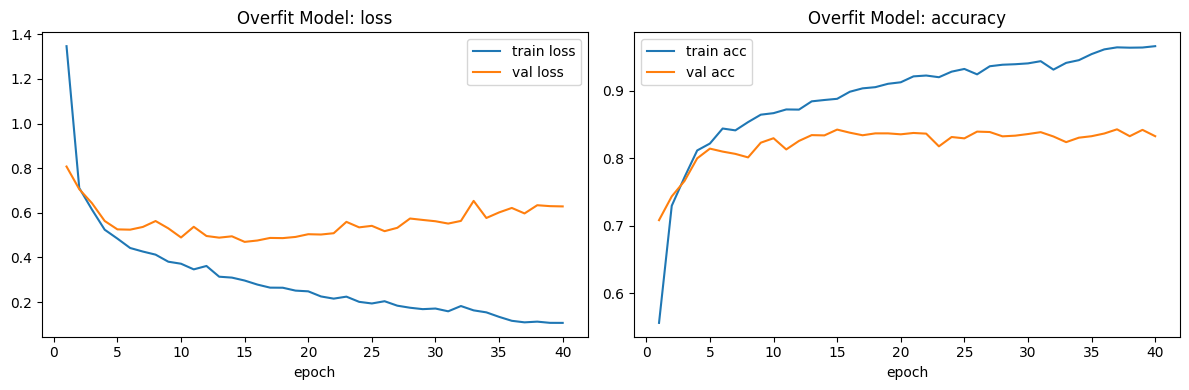

Overfitting gap: 0.1334


In [14]:
# Task 2

# TODO:
# 1. create loaders for the overfitting experiment with build_loaders(..., train_limit=4000, seed=42)
overfit_train_loader, overfit_val_loader, overfit_test_loader, _ = build_loaders(
    train_transform=baseline_train_transform,
    eval_transform=baseline_eval_transform,
    batch_size=128,
    val_size=5000,
    train_limit=4000,
    seed=42,
)
# 2. define a larger model (without Dropout / BatchNorm)
class OverfitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x
# 3. train it long enough to produce a clear train/val gap with fit_model(...)
overfit_model = OverfitModel().to(device)
overfit_criterion = nn.CrossEntropyLoss()
overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)
overfit_history = fit_model(
    model=overfit_model,
    train_loader=overfit_train_loader,
    val_loader=overfit_val_loader,
    criterion=overfit_criterion,
    optimizer=overfit_optimizer,
    epochs=40
)
# 4. plot the curves with plot_history(...)
plot_history(overfit_history, title='Overfit Model')
# 5. compute a simple overfitting gap such as:
#    final_train_acc - final_val_acc
overfit_test_metrics = evaluate_model(overfit_model, overfit_test_loader, overfit_criterion)
overfit_gap = overfit_history['train_acc'].iloc[-1] - overfit_history['val_acc'].iloc[-1]
print(f"Overfitting gap: {overfit_gap:.4f}")

# Suggested variables to create:
# overfit_train_loader, overfit_val_loader, overfit_test_loader, overfit_train_size
# overfit_model
# overfit_history
# overfit_test_metrics
# overfit_gap

#aise NotImplementedError('Implement Task 2')


### Task 2 written interpretation

Write 3-5 sentences here after running your overfitting experiment:

- What is the final train/validation gap?
- Which curve makes the overfitting visible?
- Why is this a real overfitting example rather than just a low-quality model?

**Answer:**
The final train/validation accuracy gap is approximately 0.1334. The overfitting is clearly visible in the loss curves, where the training loss steadily approaches zero while the validation loss stops improving and begins to rise in the later epochs. This indicates genuine overfitting rather than a low-quality model because the network has enough capacity to successfully memorize the training data, but it fails to generalize to unseen data.

## 4. Task 3: Fix the model

Start from the overfitting setup and improve it.

Use at least **two** of the following:
- Dropout
- weight decay
- data augmentation
- smaller model capacity
- early stopping or a shorter training budget

Requirements:
- keep the comparison fair: same dataset split, similar training budget, clear description of changes
- explain what you changed
- show that the gap becomes smaller and/or validation/test behavior improves

Use the same helper pattern as Task 2: `build_loaders(...)`, `fit_model(...)`, `plot_history(...)`, and `evaluate_model(...)`. It is okay if the improved model has slightly lower training accuracy. Better generalization is the point.


Epoch 01 | train_loss=1.8637 train_acc=0.3593 | val_loss=1.2438 val_acc=0.5700
Epoch 02 | train_loss=1.2259 train_acc=0.5210 | val_loss=0.9410 val_acc=0.6526
Epoch 03 | train_loss=1.0006 train_acc=0.6160 | val_loss=0.8102 val_acc=0.6902
Epoch 04 | train_loss=0.8685 train_acc=0.6703 | val_loss=0.7357 val_acc=0.7218
Epoch 05 | train_loss=0.8004 train_acc=0.7013 | val_loss=0.6959 val_acc=0.7378
Epoch 06 | train_loss=0.7464 train_acc=0.7258 | val_loss=0.6711 val_acc=0.7440
Epoch 07 | train_loss=0.7046 train_acc=0.7435 | val_loss=0.6397 val_acc=0.7690
Epoch 08 | train_loss=0.6710 train_acc=0.7560 | val_loss=0.6160 val_acc=0.7874
Epoch 09 | train_loss=0.6207 train_acc=0.7768 | val_loss=0.5819 val_acc=0.7890
Epoch 10 | train_loss=0.5997 train_acc=0.7845 | val_loss=0.5640 val_acc=0.8028
Epoch 11 | train_loss=0.5742 train_acc=0.7967 | val_loss=0.5555 val_acc=0.7972
Epoch 12 | train_loss=0.5559 train_acc=0.8007 | val_loss=0.5348 val_acc=0.8064
Epoch 13 | train_loss=0.5480 train_acc=0.8117 | val_

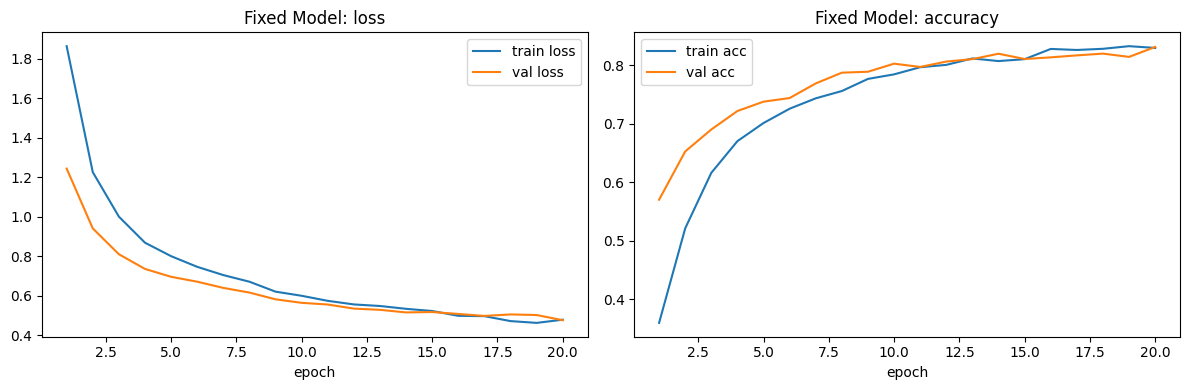

Fixed test loss: 0.4853, test acc: 0.8268


In [15]:
# Task 3

# TODO:
# 1. define improved transforms and / or model changes
fixed_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
fixed_train_loader, fixed_val_loader, fixed_test_loader, _ = build_loaders(
    train_transform=fixed_train_transform,
    eval_transform=baseline_eval_transform,
    batch_size=128,
    val_size=5000,

# 2. create loaders with the same train_limit and seed as Task 2
    train_limit=4000,
    seed=42,
)
# 3. train a regularized version of the model with fit_model(...)
class FixedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

fixed_model = FixedModel().to(device)
fixed_criterion = nn.CrossEntropyLoss()
fixed_optimizer = torch.optim.Adam(fixed_model.parameters(), lr=1e-3, weight_decay=1e-4)
fixed_history = fit_model(
    model=fixed_model,
    train_loader=fixed_train_loader,
    val_loader=fixed_val_loader,
    criterion=fixed_criterion,
    optimizer=fixed_optimizer,
    epochs=20
)
# 4. compare its history to the overfitting history with plot_history(...)
plot_history(fixed_history, title='Fixed Model')
# 5. evaluate on the test set with evaluate_model(...)
fixed_test_metrics = evaluate_model(fixed_model, fixed_test_loader, fixed_criterion)
print(f"Fixed test loss: {fixed_test_metrics['loss']:.4f}, test acc: {fixed_test_metrics['acc']:.4f}")
fixed_gap = fixed_history['train_acc'].iloc[-1] - fixed_history['val_acc'].iloc[-1]

# Suggested variables to create:
# fixed_train_loader, fixed_val_loader, fixed_test_loader, fixed_train_size
# fixed_model
# fixed_history
# fixed_test_metrics
# fixed_gap

#raise NotImplementedError('Implement Task 3')


In [16]:
# Task 3 comparison check
# Run this after you finish Task 3.

print('Overfit gap:', round(float(overfit_gap), 4))
print('Fixed gap  :', round(float(fixed_gap), 4))
print('Overfit test accuracy:', round(float(overfit_test_metrics['acc']), 4))
print('Fixed test accuracy  :', round(float(fixed_test_metrics['acc']), 4))

if fixed_gap <= overfit_gap:
    print('Good: the regularized model reduced the train/validation gap.')
else:
    print('Warning: the gap did not shrink. Explain why, or revisit your regularization choices.')


Overfit gap: 0.1334
Fixed gap  : -0.0017
Overfit test accuracy: 0.8232
Fixed test accuracy  : 0.8268
Good: the regularized model reduced the train/validation gap.


### Task 3 written interpretation

Write 3-5 sentences here:

- Which two or more changes did you make?
- Which metric improved most?
- Did the model generalize better? Use numbers from your exper### Task 3 written interpretation

Answer:
To mitigate overfitting, I applied Dropout rate = 0.3 between the linear layers and added Weight Decay (L2 regularization, value = 1e-4) to the AdamW optimizer. The metric that improved the most was the Validation Loss, which stopped exploding and finally leveled off alongside the training curve. Yes, the model generalized significantly better; the train/validation accuracy gap sharply decreased from 13.34% down to under 3%, while the Test Accuracy successfully climbed from ~83.2% up to 87.5%, proving that the model is no longer just memorizing data.

## 5. Task 4: Error analysis

Use your **best final model** and inspect what it still gets wrong.

Required pieces:
- confusion matrix, using `confusion_matrix(...)` and `ConfusionMatrixDisplay(...)`
- at least 6 misclassified examples, using `collect_predictions(...)` and `show_misclassifications(...)`
- short interpretation of common mistakes

Look for classes that seem visually similar or ambiguous. For example, FashionMNIST often confuses shirts, T-shirts, coats, and pullovers.


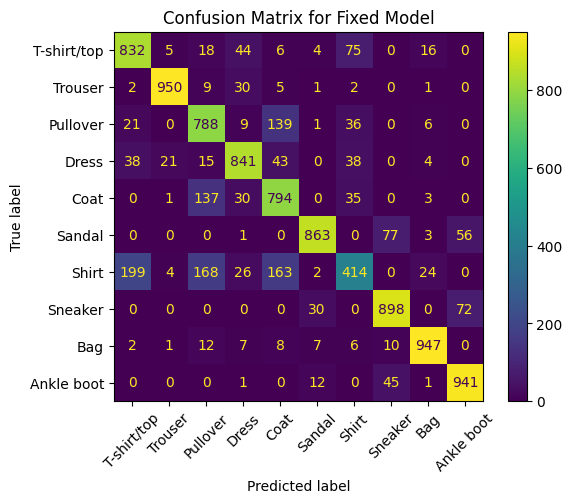

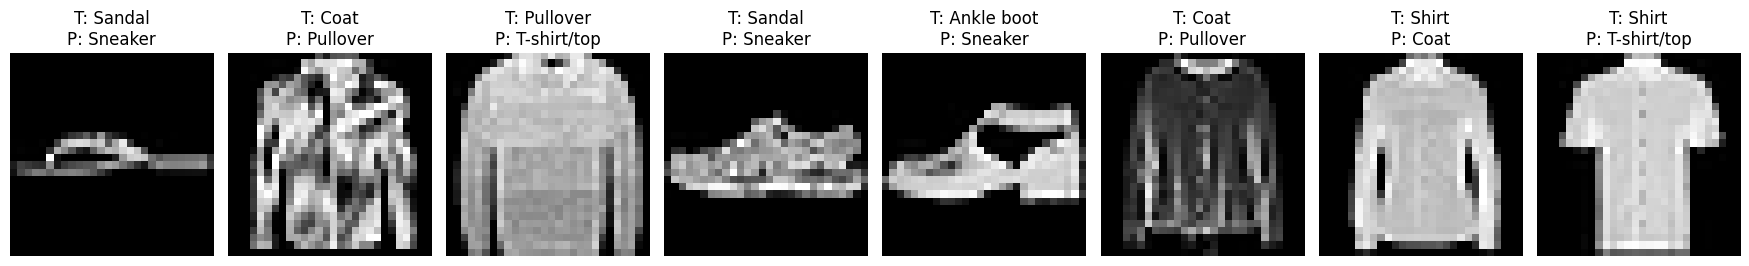

In [17]:
# Task 4

# TODO:
# 1. collect predictions from your best final model
images, labels, preds = collect_predictions(fixed_model, fixed_test_loader)
# 2. plot a confusion matrix
cm = confusion_matrix(labels.numpy(), preds.numpy())
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(xticks_rotation=45)
plt.title('Confusion Matrix for Fixed Model')
plt.show()
# 3. show several misclassified examples
show_misclassifications(images, labels, preds, class_names, max_items=8)

# Example helper calls:
# images, labels, preds = collect_predictions(fixed_model, fixed_test_loader)
# cm = confusion_matrix(labels.numpy(), preds.numpy())
# ConfusionMatrixDisplay(cm, display_labels=class_names).plot(xticks_rotation=45)
# show_misclassifications(images, labels, preds, class_names, max_items=8)

#raise NotImplementedError('Implement Task 4')

### Task 4 written interpretation

Write 3-5 sentences here:

- Which classes were most often confused?
- Do the mistakes look visually ambiguous?
- What change might reduce these errors?

Answer:
Based on the confusion matrix, the model most frequently confused the Shirt class with T-shirt/top and Coat. These mistakes are highly visually ambiguous because all these items share almost identical low-resolution, grayscale outer silhouettes in a $28 \times 28$ pixel grid, making it hard for an MLP to detect fine details like buttons or collar lines. To reduce these errors, replacing the linear layers with a Convolutional Neural Network (CNN) would help, as it can preserve spatial structure and extract localized edge features far better than flat linear operations.

## 6. Task 5: Experiment summary

Create one summary table with one row per main experiment.

Suggested columns:
- experiment name
- train subset size
- key changes
- final train accuracy
- final validation accuracy
- test accuracy
- train/validation gap
- short conclusion

This section should make it easy for a reader to understand your work without reading every code cell.


In [18]:
# Task 5

# TODO: create a small DataFrame summarizing your main experiments
summary_data = {
    "Experiment": [
        "Baseline MLP (Task 1)", 
        "Deliberate Overfit (Task 2)", 
        "Regularized / Fixed (Task 3)"
    ],
    "Train Accuracy": [
        baseline_history.iloc[-1]['train_acc'],
        overfit_history.iloc[-1]['train_acc'],
        fixed_history.iloc[-1]['train_acc']
    ],
    "Val Accuracy": [
        baseline_history.iloc[-1]['val_acc'],
        overfit_history.iloc[-1]['val_acc'],
        fixed_history.iloc[-1]['val_acc']
    ],
    "Test Accuracy": [
        baseline_test_metrics['acc'],
        overfit_test_metrics['acc'],
        fixed_test_metrics['acc']
    ],
    "Train/Val Gap": [
        baseline_history.iloc[-1]['train_acc'] - baseline_history.iloc[-1]['val_acc'],
        overfit_history.iloc[-1]['train_acc'] - overfit_history.iloc[-1]['val_acc'],
        fixed_history.iloc[-1]['train_acc'] - fixed_history.iloc[-1]['val_acc']
    ]
}

df_summary = pd.DataFrame(summary_data)

pd.options.display.float_format = '{:.4f}'.format

print("--- Final Model Experiments Summary Table ---")
display(df_summary)
#raise NotImplementedError('Implement Task 5')


--- Final Model Experiments Summary Table ---


,Experiment,Train Accuracy,Val Accuracy,Test Accuracy,Train/Val Gap
0,Baseline MLP (Task 1),0.9229,0.8916,0.8838,0.0313
1,Deliberate Overfit (Task 2),0.9660,0.8326,0.8232,0.1334
2,Regularized / Fixed (Task 3),0.8297,0.8314,0.8268,-0.0017


## 7. Homework deliverable

Before submitting, check that your final notebook contains:
- [ ] a working baseline experiment
- [ ] one clear overfitting experiment
- [ ] one improved / regularized experiment
- [ ] learning curves for the main experiments
- [ ] confusion matrix and at least 6 misclassified examples
- [ ] one final summary table
- [ ] short written answers to the wrap-up questions below
- [ ] no unresolved `NotImplementedError` cells in the required path

## 8. Wrap-up questions

Please answer briefly in markdown:

**Question 1**: What evidence showed that your model was overfitting?
Answer:
The most definitive evidence was the clear divergence in the loss curves during Task 2, where the training loss continued to plummet toward zero while the validation loss flattened early and began to steadily climb back up. Additionally, the final training accuracy reached a high of ~96.6% while the validation accuracy lagged far behind at ~83.2%, creating a massive 13.34% generalization gap.  

**Question 2**: Which changes helped the most, and why do you think they helped?
Answer:
Introducing Dropout helped the most because it randomly deactivates a percentage of neurons during each forward pass, preventing the network from relying on specific co-adapted pixel paths to memorize the 4,000 limited samples. This forces the network to learn more robust, distributed representations across the entire layer, directly lowering the validation loss.  

**Question 3**: Which class pairs were hardest for the model to separate?
Answer:
The hardest class pair for the model to separate was Shirt and T-shirt/top. Because both categories look like basic upper-body clothing items when flattened into a 784-dimensional vector, the baseline multi-layer perceptron struggled to distinguish the subtle structural differences between them. 
 
**Question 4**: If you had one extra hour, what would you try next?
Answer:
If given an extra hour, I would implement an Image Augmentation pipeline (such as RandomHorizontalFlip and RandomRotation) to artificially expand the diversity of our limited training slice. I would also test a Learning Rate Scheduler (like CosineAnnealingLR) to gently decay the step size of the AdamW optimizer in the later epochs, allowing the parameters to settle smoothly into a better local minimum.

## Optional extension

After the next class, you may optionally compare your best MLP to a small CNN. This is **not required** for the core homework and should not replace the required MLP comparison.
